# ARMA Order Determination

The $\text{ARMA}(p,q)$ process is defined by,

$
\begin{align}
X_t = \varepsilon_t + \sum_{i=1}^p \varphi_i X_{t-i} + \sum_{i=1}^q \vartheta_i \varepsilon_{t-i}
\end{align}
\tag{1}
$

where,

$
\begin{align}
\varepsilon_t \sim \text{Normal}(0, \sigma^2)
\end{align}
\tag{2}
$

Typically a time series is either $\text{AR}(p)$ or $\text{MA}(q)$. When calibrating a time series to an $\text{AR}(p)$
or $\text{MA}(q)$ process a method is needed to determine the values of $p$ and $q$. For an $\text{MA}(q)$ process
the autocorrelation function (ACF) is used. The ACF is defined by,

$
\begin{align}
\rho_\tau = \frac{\text{E}[X_t X_{t+\tau}]}{\text{E}[X_t^2]}
\end{align}
\tag{3}
$

For values of $\tau > q$ the ACF is zero for an $\text{MA}(q)$ process.

Similarly, for an $\text{AR}(p)$ process the partial autocorrelation function (PACF) is used. The PACF
is computed using the Yule-Walker equations. Recall that the Yule-Walker equations relate the autocorrelation
function to the $\text{AR}(p)$ coefficients $\varphi_i$. Define the matrices,

$
\begin{align}
\hat{r} =
\begin{bmatrix}
\rho_1 \\
\rho_2 \\
\rho_3 \\
\vdots \\
\rho_{p-1} \\
\rho_{p}
\end{bmatrix}
\end{align}
\tag{4}
$

$
\begin{align}
\hat{\Phi} =
\begin{bmatrix}
\varphi_1 \\
\varphi_2 \\
\varphi_3 \\
\vdots \\
\varphi_{p-1} \\
\varphi_{p}
\end{bmatrix}
\end{align}
\tag{5}
$

$
\begin{align}
\hat{R} =
\begin{bmatrix}
1 & \rho_1 & \rho_2 & \cdots & \rho_{p-2} & \rho_{p-1} \\
\rho_1 & 1 & \rho_1 & \cdots & \rho_{p-3} & \rho_{p-2} \\
\rho_2 & \rho_1 & 1 & \cdots & \rho_{p-4} & \rho_{p-3} \\
\vdots & \vdots  & \vdots & \ddots & \vdots & \vdots \\
\rho_{p-2} & \rho_{p-3} & \rho_{p-4} & \cdots & 1 & \rho_1 \\
\rho_{p-1} & \rho_{p-2} & \rho_{p-3} & \cdots & \rho_1 & 1 \\
\end{bmatrix}
\end{align}
\tag{6}
$

Then the Yule-Walker equations are given by,

$
\begin{align}
\hat{\Phi} = \hat{R}^{-1} \hat{r}
\end{align}
\tag{7}
$

So, the partial autocorrelation function, PACF, is given by,

$
\begin{align}
\hat{R}^{-1} \hat{r}
\end{align}
\tag{8}
$

For lags grater than the time series order $p$ the PACF is zero. Combining these give a method
for determining the order of an $\text{ARMA}(p,q)$ process.

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import sys
import os
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import arima, stats
from lib.plots import stack, twinx
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
σ = 1
nsample = 1000
nlags = 10

def ar_comparison(φ_vals, title, ylim, *params):
    labels = [f"φ={val}" for val in φ_vals]
    source = lambda **kwargs : arima.create_ar_source(**kwargs)
    ylabels = r"$S_t$"
    t, scan = create_parameter_scan(source, *params)
    stack(scan, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel="Time", figsize=(10, 6))
    return t, scan

def ma_comparison(θ_vals, title, ylim, *params):
    labels = [f"θ={val}" for val in θ_vals] 
    source = lambda **kwargs : arima.create_ma_source(**kwargs)
    ylabels = r"$S_t$"
    t, scan = create_parameter_scan(source, *params)
    stack(scan, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel="Time", figsize=(10, 6))
    return t, scan

def pacf_acf_plot(t, samples, nlags, ylim, title):
    tacf, acf = stats.compute_acf(t, samples, nlags=nlags)
    tpacf, pacf = arima.compute_pacf(samples, nlags=nlags)
    twinx(acf, pacf, [tacf, tpacf], ylim=ylim, title=title, figsize=(10, 6), labels=["ACF", "PACF"])

## $\text{AR}(p)$

### AR(1) Simulations

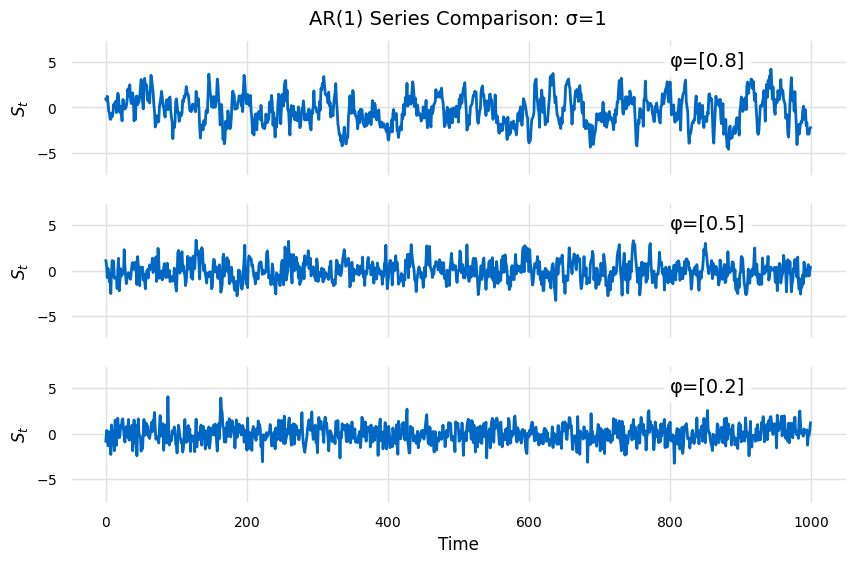

In [3]:
title = f"AR(1) Series Comparison: σ={σ}"
φ_vals = [[0.8], [0.5], [0.2]]
params = [{"φ": φ, "σ": σ, "npts": nsample} for φ in φ_vals]
t, ar = ar_comparison(φ_vals, title, [-7.5, 7.5], *params)

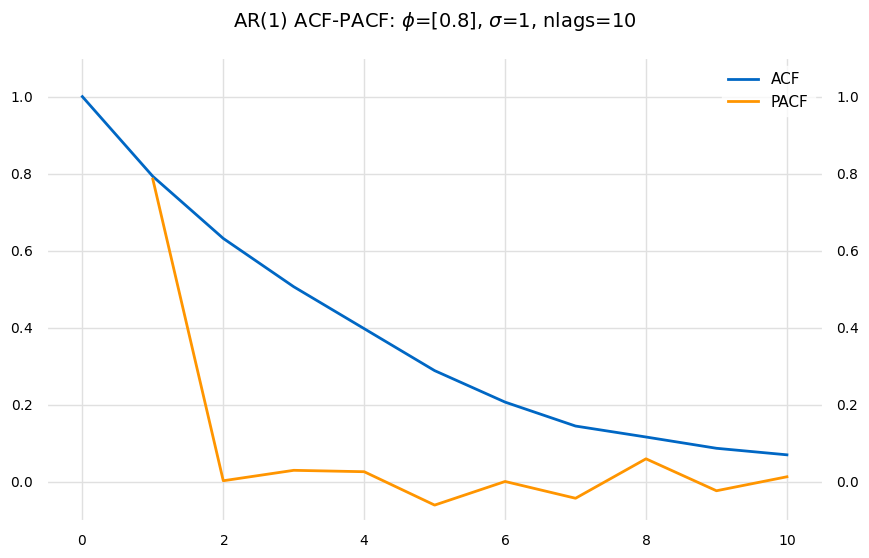

In [4]:
title = f"AR(1) ACF-PACF: $\phi$={φ_vals[0]}, $\sigma$={σ}, nlags={nlags}"
pacf_acf_plot(t[0], ar[0], nlags, [-0.1, 1.1], title)

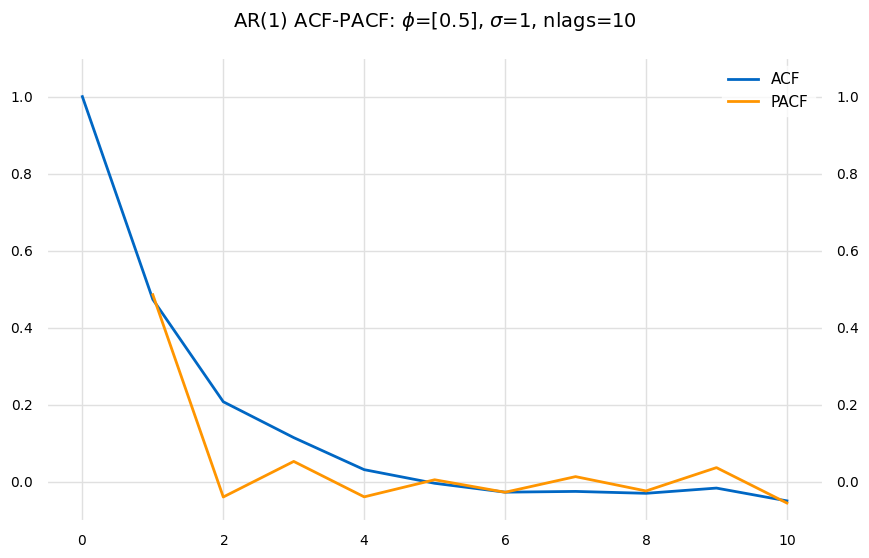

In [5]:
title = f"AR(1) ACF-PACF: $\phi$={φ_vals[1]}, $\sigma$={σ}, nlags={nlags}"
pacf_acf_plot(t[1], ar[1], nlags, [-0.1, 1.1], title)

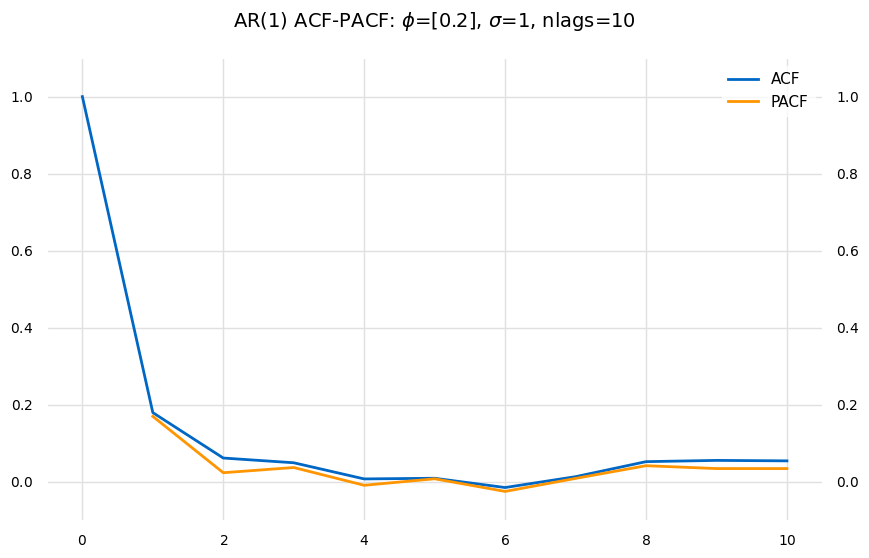

In [6]:
title = f"AR(1) ACF-PACF: $\phi$={φ_vals[2]}, $\sigma$={σ}, nlags={nlags}"
pacf_acf_plot(t[2], ar[2], nlags, [-0.1, 1.1], title)

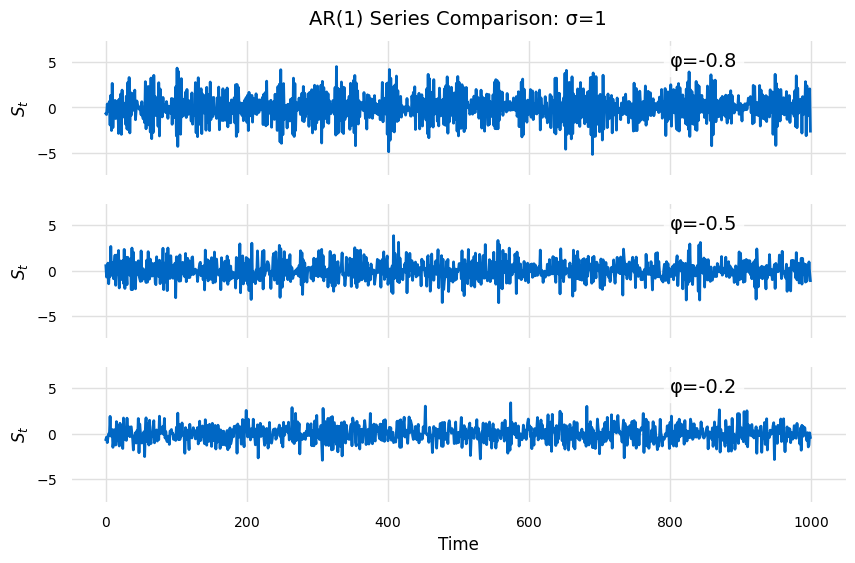

In [7]:
title = f"AR(1) Series Comparison: σ={σ}"
φ_vals = [-0.8, -0.5, -0.2]
params = [{"φ": [φ], "σ": σ, "npts": nsample} for φ in φ_vals]
t, ar = ar_comparison(φ_vals, title, [-7.5, 7.5], *params)

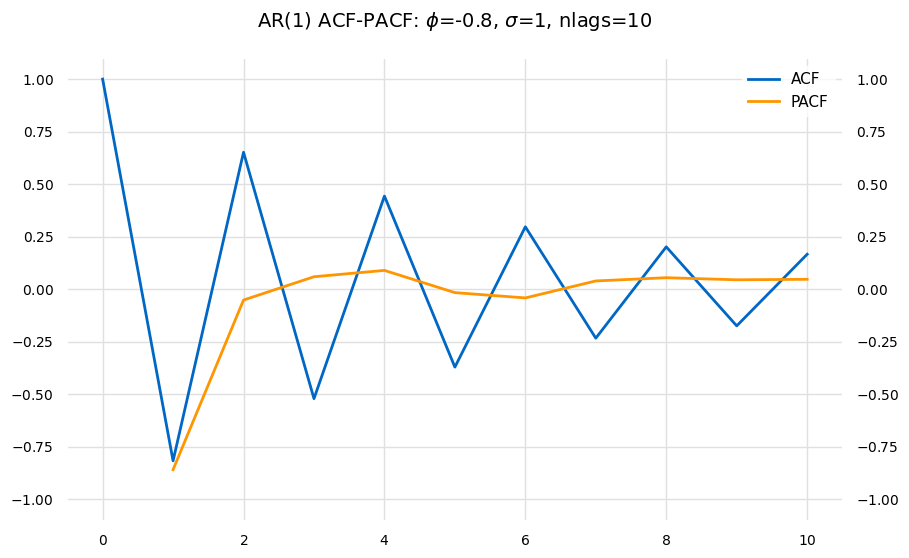

In [8]:
title = f"AR(1) ACF-PACF: $\phi$={φ_vals[0]}, $\sigma$={σ}, nlags={nlags}"
pacf_acf_plot(t[0], ar[0], nlags, [-1.1, 1.1], title)

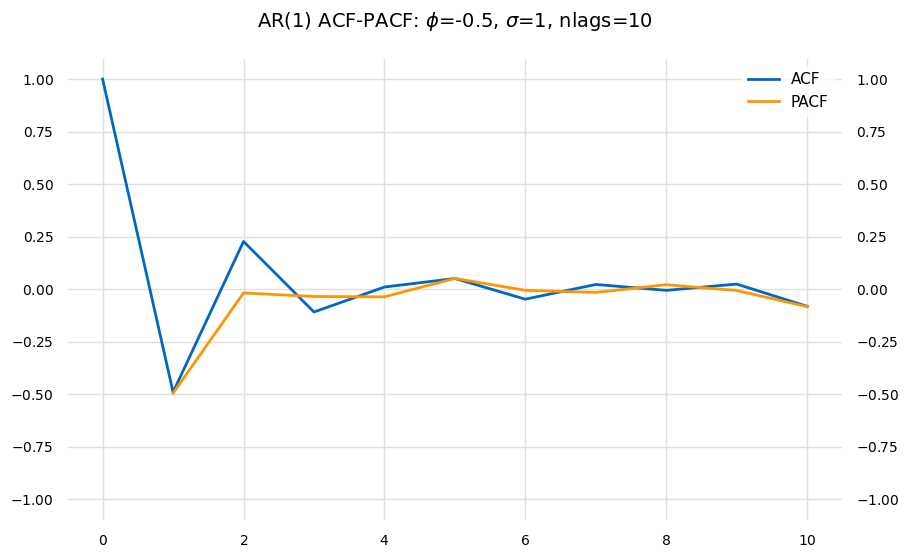

In [9]:
title = f"AR(1) ACF-PACF: $\phi$={φ_vals[1]}, $\sigma$={σ}, nlags={nlags}"
pacf_acf_plot(t[1], ar[1], nlags, [-1.1, 1.1], title)

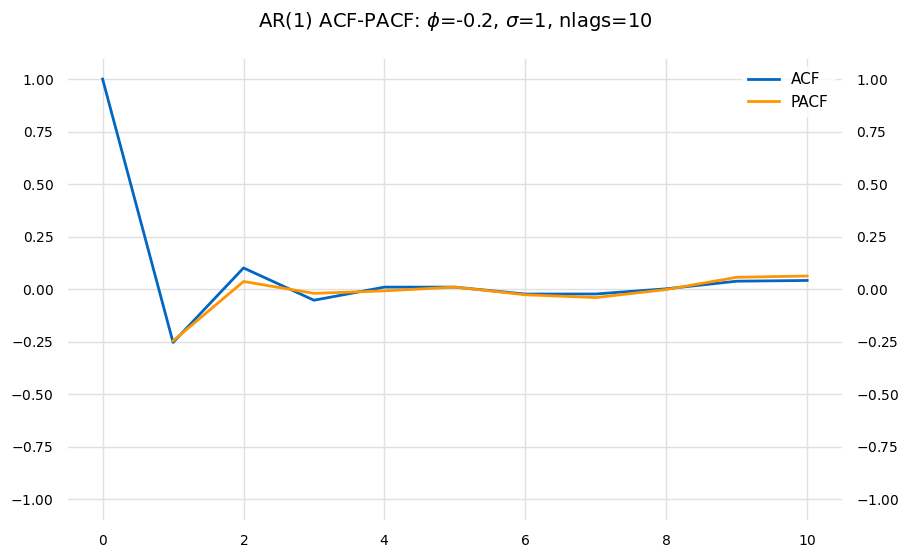

In [10]:
title = f"AR(1) ACF-PACF: $\phi$={φ_vals[2]}, $\sigma$={σ}, nlags={nlags}"
pacf_acf_plot(t[2], ar[2], nlags, [-1.1, 1.1], title)

### AR(2) and AR(3) Simulations

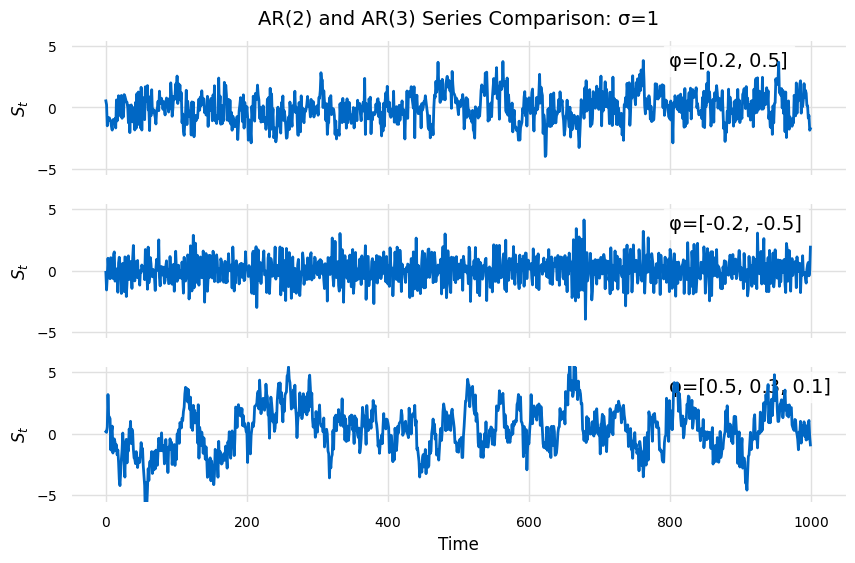

In [11]:
title = f"AR(2) and AR(3) Series Comparison: σ={σ}"
φ_vals = [[0.2, 0.5],[-0.2, -0.5], [0.5, 0.3, 0.1]]
params = [{"φ": φ, "σ": σ, "npts": nsample} for φ in φ_vals]
t, ar = ar_comparison(φ_vals, title, [-5.5, 5.5], *params)

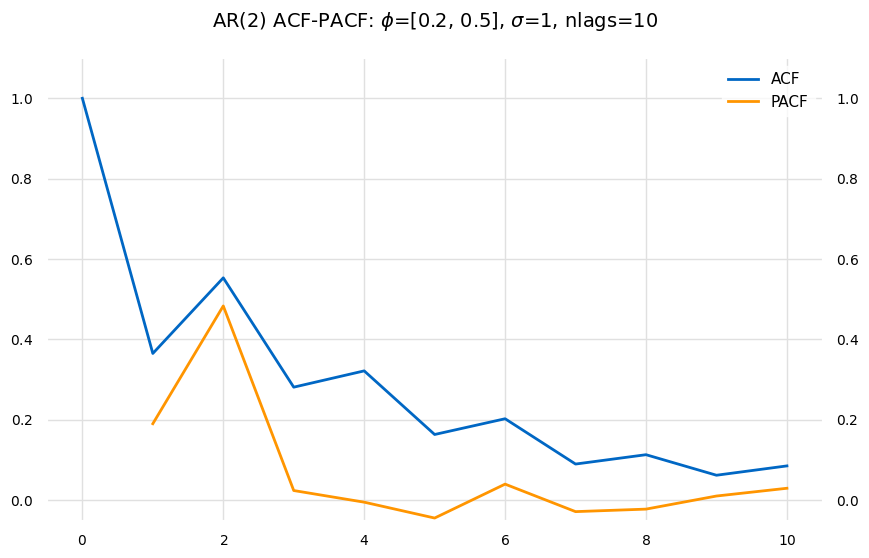

In [12]:
title = f"AR(2) ACF-PACF: $\phi$={φ_vals[0]}, $\sigma$={σ}, nlags={nlags}"
pacf_acf_plot(t[0], ar[0], nlags,  [-0.05, 1.1], title)

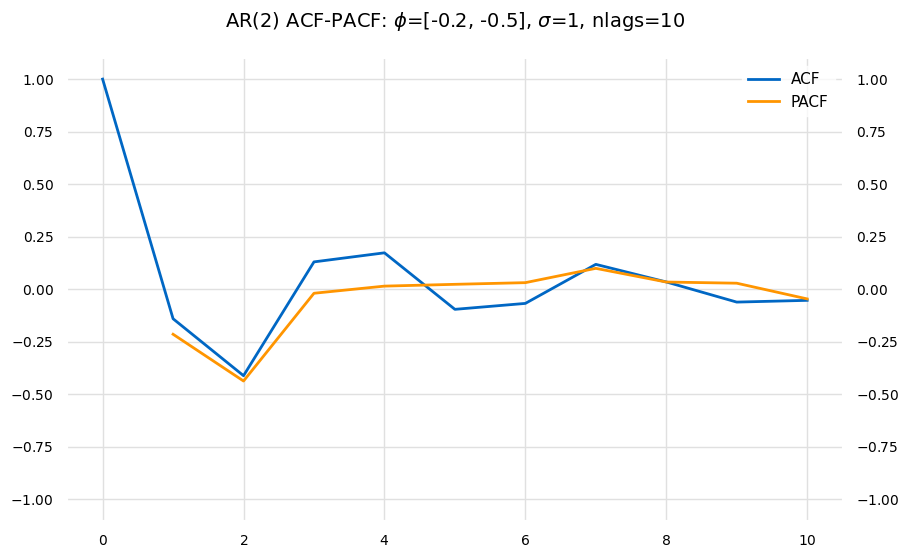

In [13]:
title = f"AR(2) ACF-PACF: $\phi$={φ_vals[1]}, $\sigma$={σ}, nlags={nlags}"
pacf_acf_plot(t[1], ar[1], nlags,  [-1.1, 1.1], title)

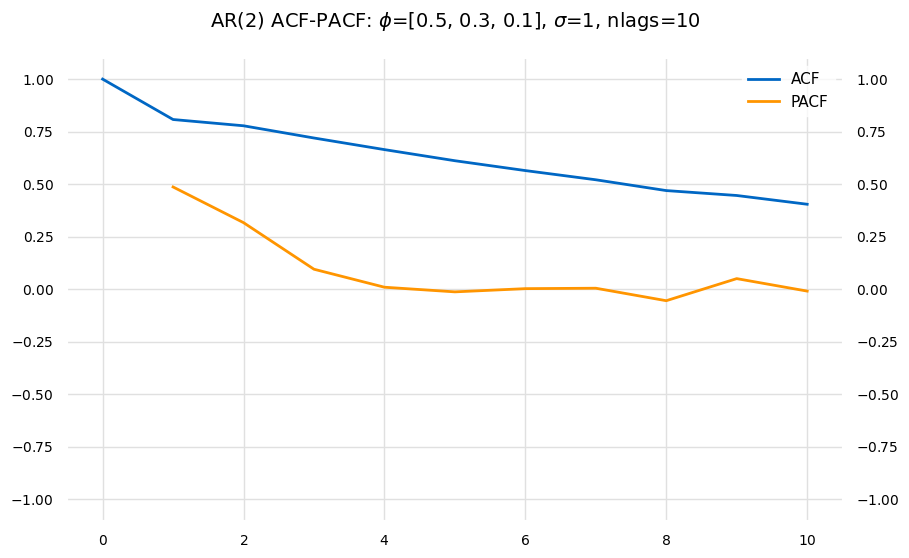

In [14]:
title = f"AR(2) ACF-PACF: $\phi$={φ_vals[2]}, $\sigma$={σ}, nlags={nlags}"
pacf_acf_plot(t[2], ar[2], nlags,  [-1.1, 1.1], title)

## $\text{MA}(q)$

### MA(1) Simulations

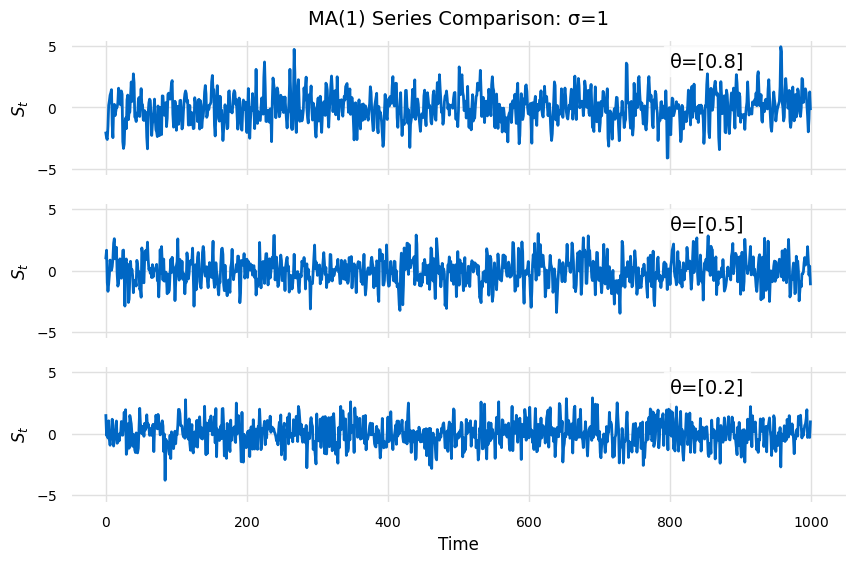

In [15]:
title = f"MA(1) Series Comparison: σ={σ}"
θ_vals = [[0.8], [0.5],[0.2]]
params = [{"θ": θ, "σ": σ, "npts": nsample} for θ in θ_vals]
t, ma = ma_comparison(θ_vals, title, [-5.5, 5.5], *params)

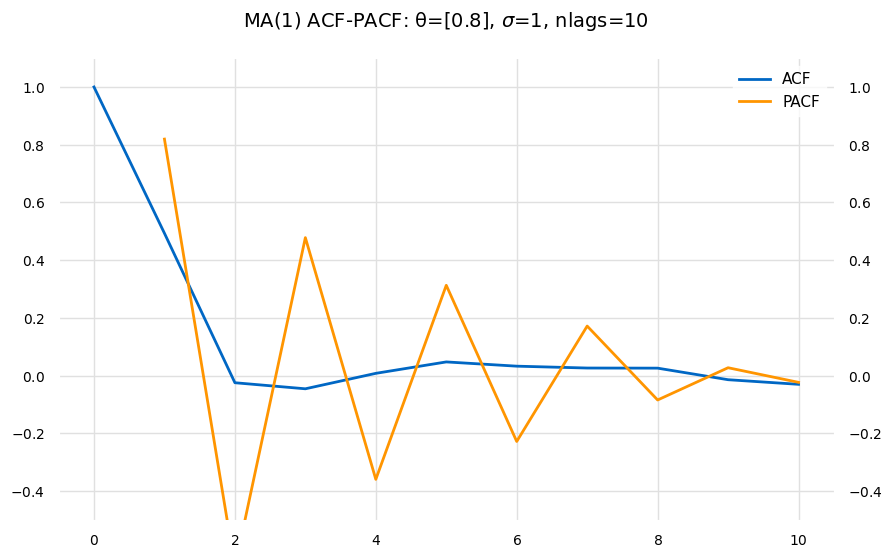

In [16]:
title = f"MA(1) ACF-PACF: θ={θ_vals[0]}, $\sigma$={σ}, nlags={nlags}"
pacf_acf_plot(t[0], ma[0], nlags,  [-0.5, 1.1], title)

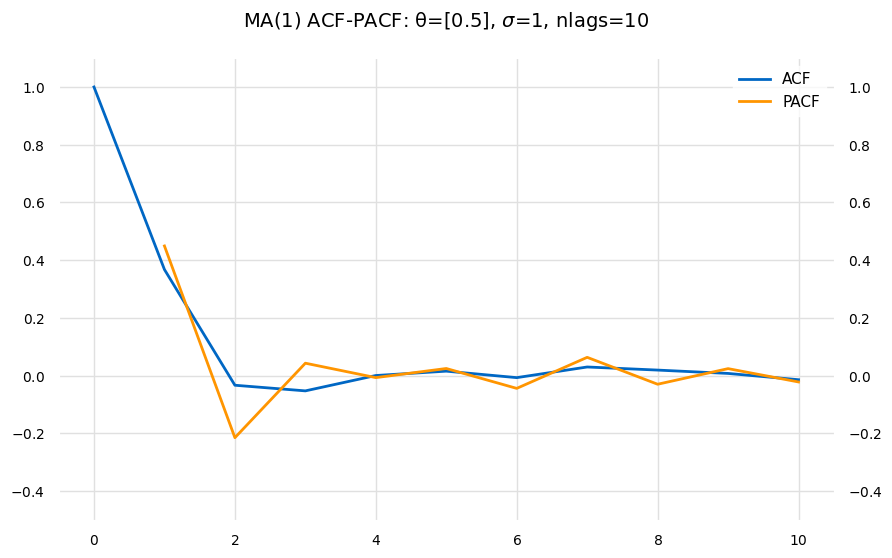

In [17]:
title = f"MA(1) ACF-PACF: θ={θ_vals[1]}, $\sigma$={σ}, nlags={nlags}"
pacf_acf_plot(t[1], ma[1], nlags,  [-0.5, 1.1], title)

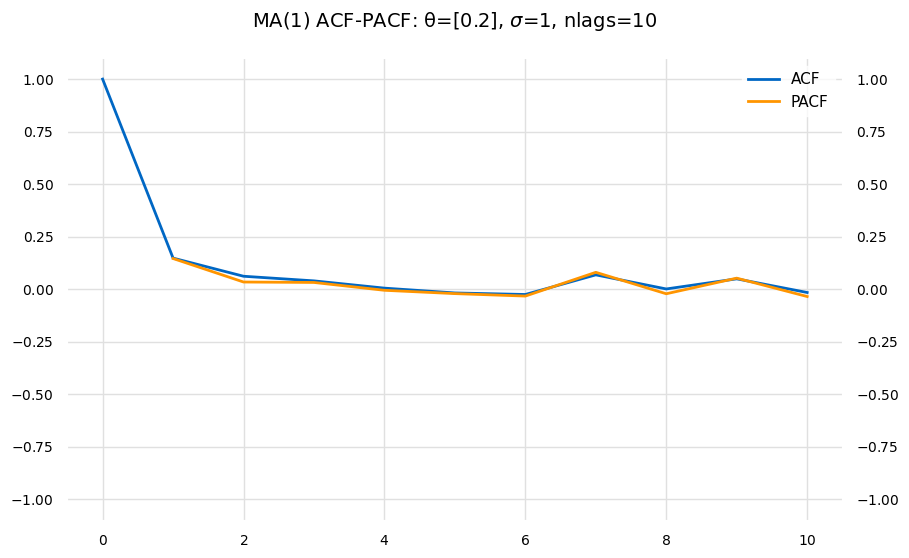

In [18]:
title = f"MA(1) ACF-PACF: θ={θ_vals[2]}, $\sigma$={σ}, nlags={nlags}"
pacf_acf_plot(t[2], ma[2], nlags, [-1.1, 1.1], title)

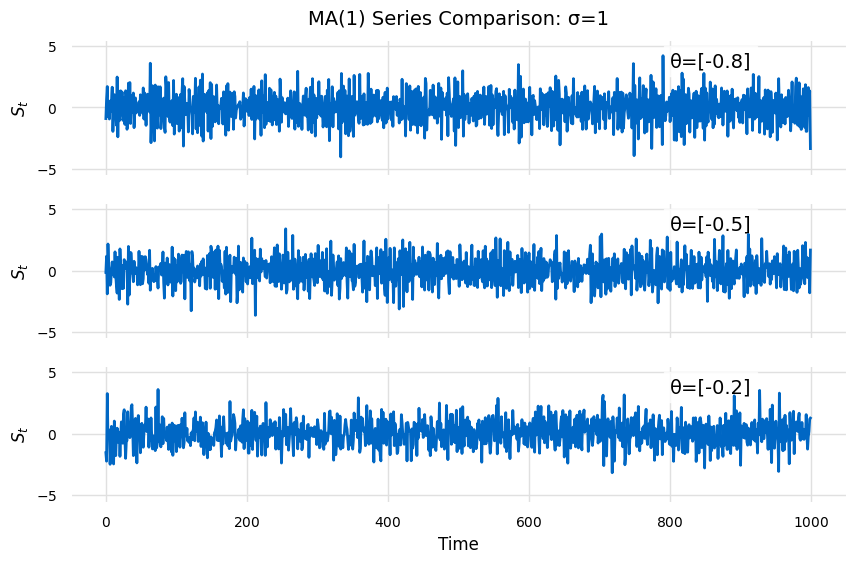

In [19]:
title = f"MA(1) Series Comparison: σ={σ}"
θ_vals = [[-0.8], [-0.5],[-0.2]]
params = [{"θ": θ, "σ": σ, "npts": nsample} for θ in θ_vals]
t, ma = ma_comparison(θ_vals, title, [-5.5, 5.5], *params)

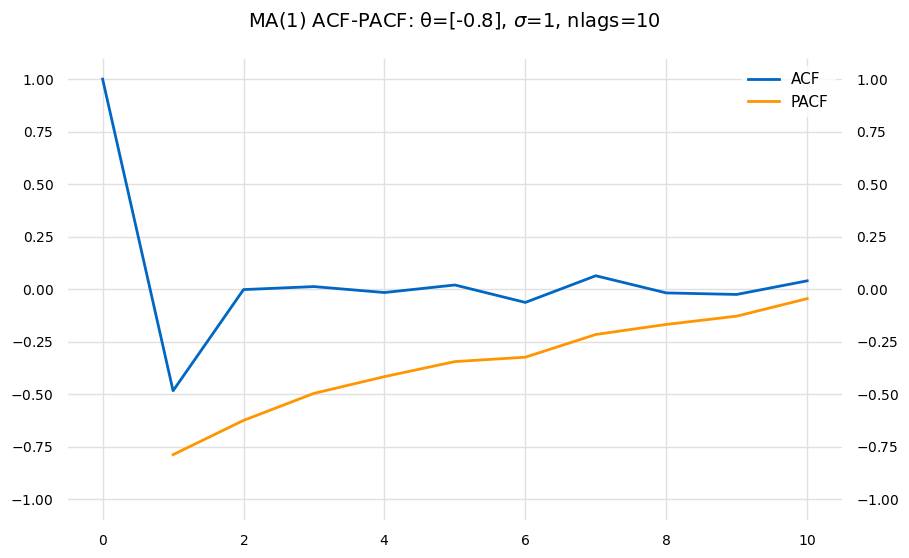

In [20]:
title = f"MA(1) ACF-PACF: θ={θ_vals[0]}, $\sigma$={σ}, nlags={nlags}"
pacf_acf_plot(t[0], ma[0], nlags, [-1.1, 1.1], title)

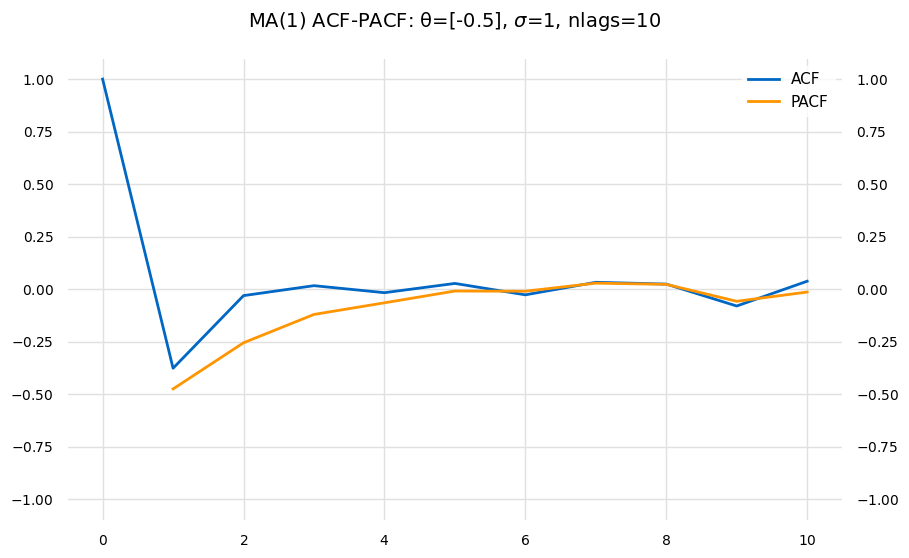

In [21]:
title = f"MA(1) ACF-PACF: θ={θ_vals[1]}, $\sigma$={σ}, nlags={nlags}"
pacf_acf_plot(t[1], ma[1], nlags, [-1.1, 1.1], title)

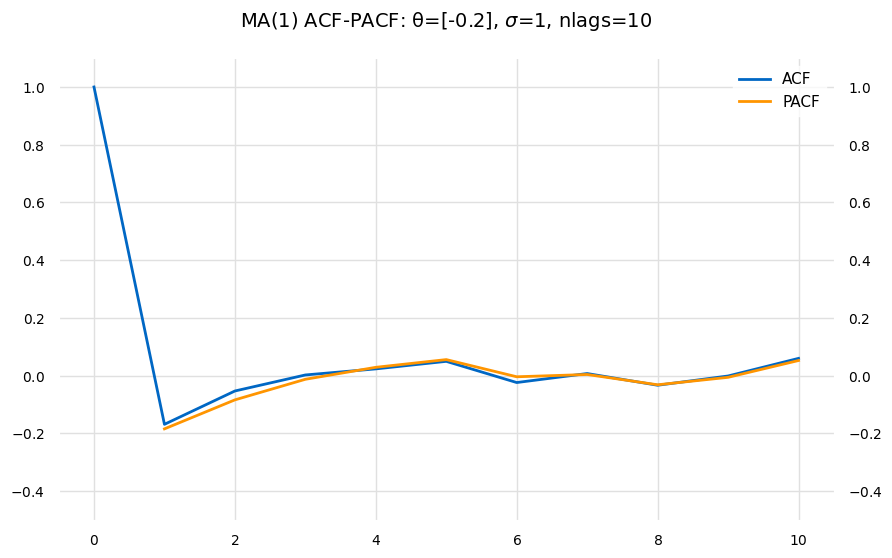

In [22]:
title = f"MA(1) ACF-PACF: θ={θ_vals[2]}, $\sigma$={σ}, nlags={nlags}"
pacf_acf_plot(t[2], ma[2], nlags, [-0.5, 1.1], title)

### MA(2) and MA(3) Simulations

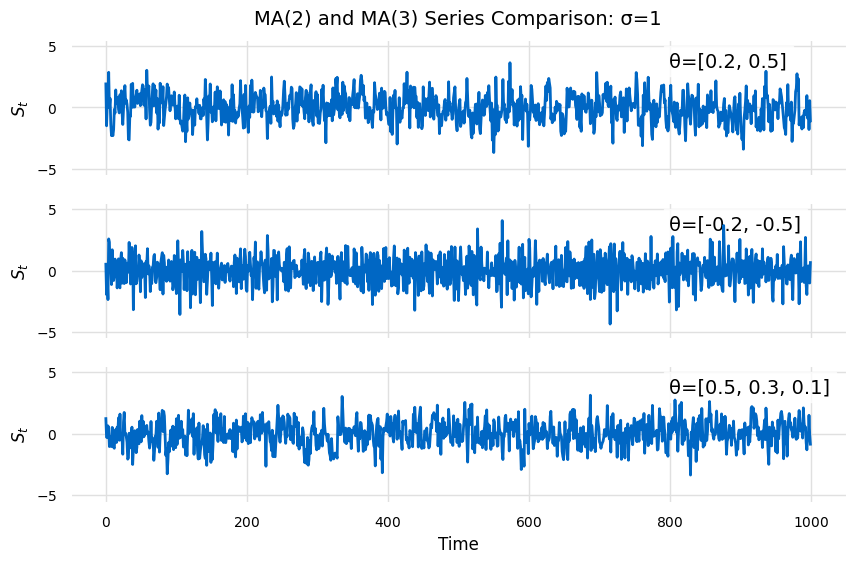

In [23]:
title = f"ΜΑ(2) and MA(3) Series Comparison: σ={σ}"
θ_vals = [[0.3, 0.4], [-0.3, -0.4], [0.2, 0.3, 0.2]]
params = [{"θ": θ, "σ": σ, "npts": nsample} for θ in θ_vals]
t, ma = ma_comparison(φ_vals, title, [-5.5, 5.5], *params)

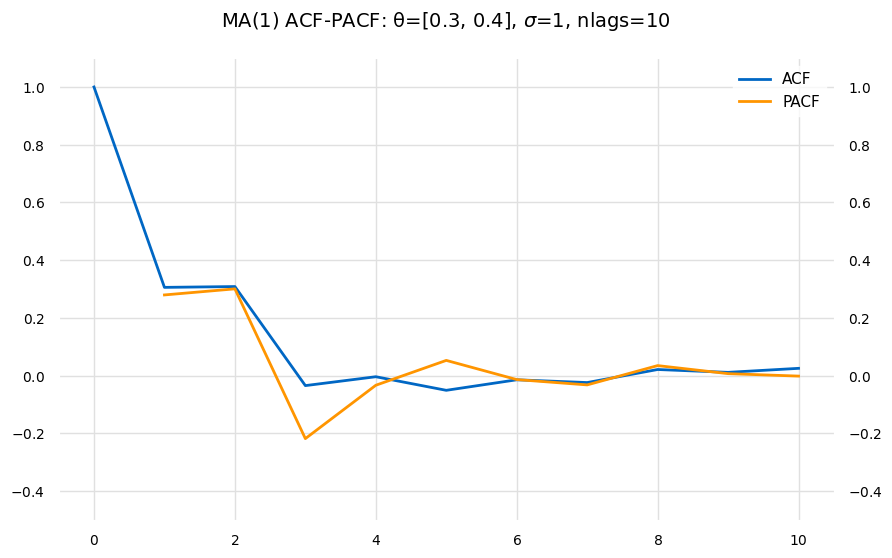

In [24]:
title = f"MA(1) ACF-PACF: θ={θ_vals[0]}, $\sigma$={σ}, nlags={nlags}"
pacf_acf_plot(t[0], ma[0], nlags, [-0.5, 1.1], title)

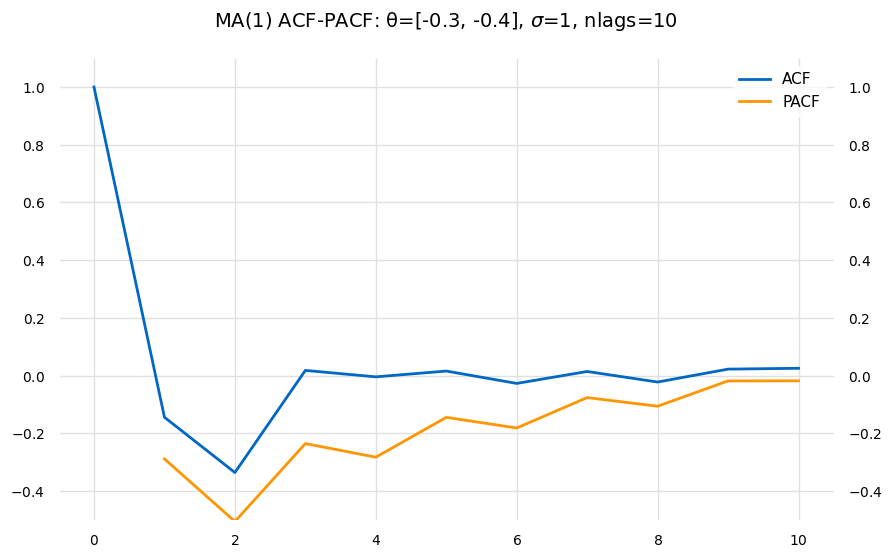

In [25]:
title = f"MA(1) ACF-PACF: θ={θ_vals[1]}, $\sigma$={σ}, nlags={nlags}"
pacf_acf_plot(t[1], ma[1], nlags, [-0.5, 1.1], title)

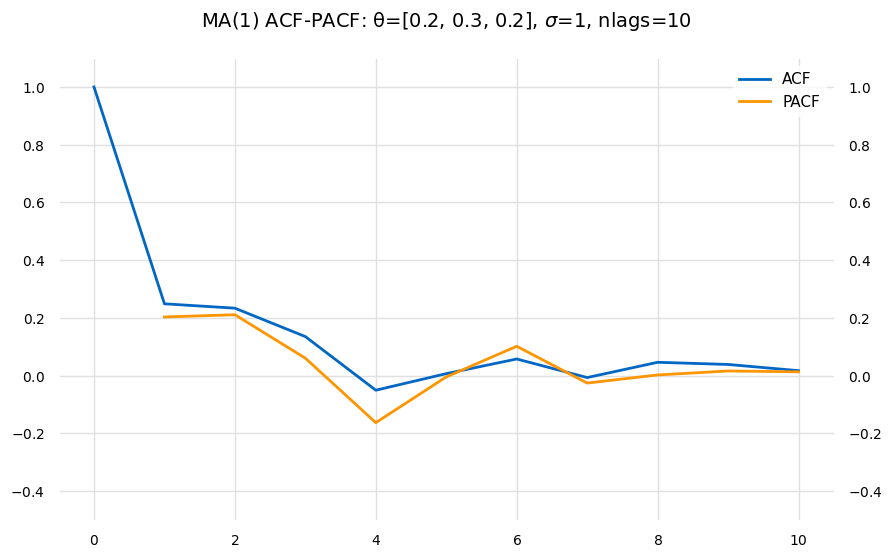

In [26]:
title = f"MA(1) ACF-PACF: θ={θ_vals[2]}, $\sigma$={σ}, nlags={nlags}"
pacf_acf_plot(t[2], ma[2], nlags, [-0.5, 1.1], title)